# SciPy: Optimization

## 1. Mathematical foundations

### 1.1. Principles of convexity

#### Convex set
A set $\mathcal{S}$ is convex if the line between any two points $s_1,s_2\in\mathcal{S}$ lies completely inside $\mathcal{S}$. Formally:

$$\lambda s_1+(1-\lambda)s_2\in \mathcal{S}\qquad\forall\;\lambda\in[0,1]$$

:::{image} ../image/chap_02/convex_set.svg
:height: 200px
:align: center
:::

#### Convex function
A function $f(x)$ is convex if (1) its domain is convex and (2) the curve between any two points $x_1,x_2\in\text{dom}(f)$ lies under the segment between them:

$$f(\lambda x_1+(1-\lambda)x_2)\leq\lambda f(x_1)+(1-\lambda)f(x_2)\qquad\forall\;\lambda\in[0,1]$$

Equivalently, $f(x)$ is also convex if it satisfies one of these (differentiability assumed):
- First-order condition: The tangent line at any point lies below the graph of the function: $f(x_2)\geq f(x_1)+\nabla f(x_1)^\top(x_2-x_1)$
- Second-order condition: The function is curved upward in all directions (think of a bowl): $\nabla^2f(x)\succeq0$

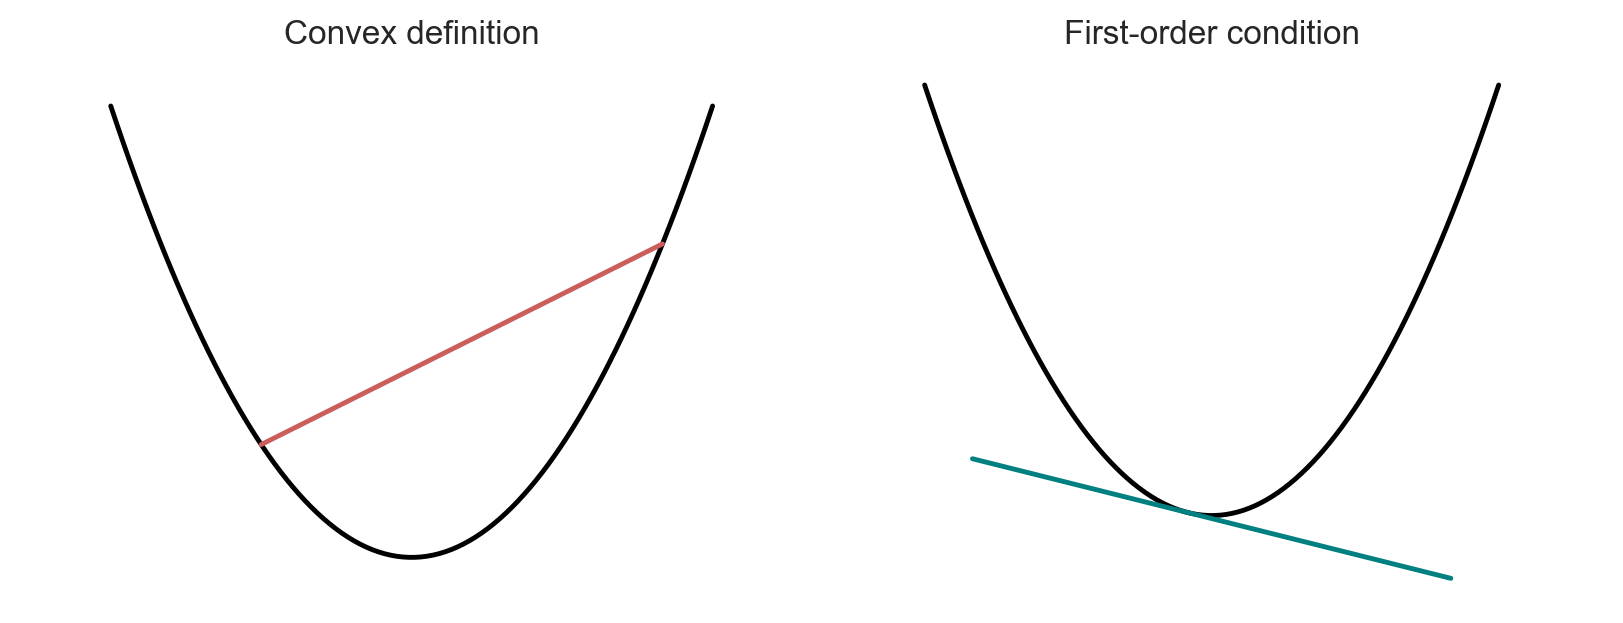

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, plt, sns

def f(x):
    return x ** 2 / 2

x_graph = np.linspace(-3, 3, 100)
y_graph = f(x_graph)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(8,3))
ax[0].plot(x_graph, y_graph, 'k')
ax[0].axis('equal')
ax[0].grid(False)
ax[0].set_axis_off()
ax[0].set_title('Convex definition')

x_dom = np.array([-1.5, 2.5])
y_dom = f(x_dom)
ax[0].plot(x_dom, y_dom, 'indianred')

ax[1].plot(x_graph, y_graph, 'k')
ax[1].axis('equal')
ax[1].grid(False)
ax[1].set_axis_off()
ax[1].set_title('First-order condition')

def tangent_line(x):
    return -0.25*x - 0.03125

x_tng = np.array([-2.5, 2.5])
y_tng = tangent_line(x_tng)
ax[1].plot(x_tng, y_tng, 'teal')

plt.show()

:::{note}
- Any local minimum of a convex function $f$ is also its global minimum.
- If $f$ is convex then $-f$ is concave, whose domain is still a convex set. There is no such thing as "a concave set".
:::

### 1.2. Derivative tests

### 1.3. Matrix definiteness
[Matrix definiteness] is the matrix version of "a scalar being positive or negative". It shows up everywhere in optimization because Hessians are (usually) symmetric, and their definiteness tells you about curvature (convex/concave).

[Matrix definiteness]: https://en.wikipedia.org/wiki/Definite_matrix

#### Definition and intuition
Positive definite is a direct generalization of "positive":
- A scalar is positive ($a>0$) if multiplying by $a$ preserves the sign of any number $x\neq0$: Formally: $x(ax)>0$.
- A matrix is positive definite ($\mathbf{A}\succ0$) if the transformation $\mathbf{A}$ never flips any vector $\mathbf{x}\neq\mathbf{0}$ into a negative direction. Formally: $\mathbf{x}^\top (\mathbf{Ax}) > 0$.

:::{note}
In practice, definiteness is usually discussed for square, symmetric matrices, which is exactly the case for Hessians in most optimization problems.
:::

#### Types and notation
Let $\mathbf{A} \in \mathbb{R}^{N\times N}$ be symmetric.

|Type of definiteness|Notation|Scalar version|Definition|
|:-|:-:|:-:|:-|
|Positive definite| $\mathbf{A}\succ0$ | $a>0$ | $\mathbf{x}^\top\mathbf{Ax}>0\;\forall\;\mathbf{x}\neq\mathbf{0}$ |
|Negative definite| $\mathbf{A}\prec0$ | $a<0$ | $\mathbf{x}^\top\mathbf{Ax}<0\;\forall\;\mathbf{x}\neq\mathbf{0}$ |
|Positive semi-definite| $\mathbf{A}\succeq0$ | $a\geq0$| $\mathbf{x}^\top\mathbf{Ax}\geq0\;\forall\;\mathbf{x}$ |
|Negative semi-definite| $\mathbf{A}\preceq0$ | $a\leq0$| $\mathbf{x}^\top\mathbf{Ax}\leq0\;\forall\;\mathbf{x}$ |
|Non-definite||| $\exists\;\mathbf{x}:\mathbf{x}^\top\mathbf{Ax}>0;\;\exists\;\mathbf{y}:\mathbf{y}^\top\mathbf{Ay}>0$ |
|Shifted positive definite| $\mathbf{A}\succ\mu$ | $a>\mu$ | $\mathbf{A}-\mu\mathbf{I}\succ0$

### Definiteness tests
You can check definiteness in a few standard ways (again, assume $\mathbf{A} \in \mathbb{R}^{N\times N}$ is symmetric).
- Quadratic test (definition): look at $\mathbf{x}^\top\mathbf{Ax}$ and use the definitions. This is the most direct test, but not always the easiest to compute.
- Spectral test: check eigenvalues $\lambda_n$.
    - If all are positive or negative then $\mathbf{A}$ is definite
    - If all are $\geq0$ or $\leq0$ then $\mathbf{A}$ is semi-definite
    - If some are positive and some are negative then $\mathbf{A}$ is non-definite
- Sylvester test: check determinants of all leading principal minors $\det(\mathbf{A}_{1:n,1:n})$.
    - If all are positive then $\mathbf{A}$ is positive definite
    - If they have alternating signs, starting from positive, then $\mathbf{A}$ is nagative definite.

## 2. Unconstrained Optimization

### 2.1. Theoretical frameworks

### 2.2. Practical algorithms

## 3. Constrained Optimization

### 3.1. Lagrange multipliers

### 3.2. KKT conditions

### 3.3. Duality in Machine Learning

## 4. Optimization in practice

### 4.1. Problem classification

### 4.2. Implementation: SciPy

### 4.3. Implementation: OR-Tools